In [1]:
%load_ext autoreload
%autoreload 2

In [58]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stellarhalo
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import cosmo as co

In [30]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [31]:
test140 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e10, verbose=False)

test138 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.8.npz", mass_threshold=10**(9.8), verbose=False)

test136 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.6.npz", mass_threshold=10**(9.6), verbose=False)

test134 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.4.npz", mass_threshold=10**(9.4), verbose=False)

test132 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.2.npz", mass_threshold=10**(9.2), verbose=False)

test130 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.0.npz", mass_threshold=1e9, verbose=False)

In [47]:
satgen500 = pd.read_csv("../../data/vdb/N500/summary_tabs/artificial_all.csv")
satnorm = jsm_simload.NormalizeData(satgen500, dataset_title="SatGen")
# satnorm.plot_bestfit("../../figures/satgen_fit.pdf", col="C0")

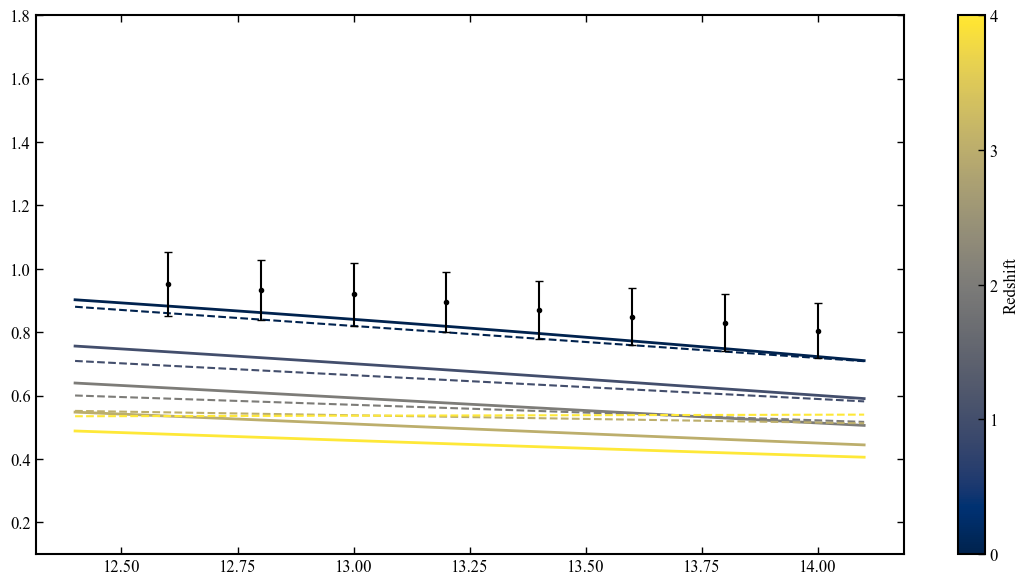

In [79]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

halo_smooth = np.linspace(12.4, 14.1, 25)
z_discrete = np.arange(0, 5)

# Choose a colormap
cmap = plt.cm.cividis
norm = mpl.colors.Normalize(vmin=z_discrete.min(), vmax=z_discrete.max())
# Colors for each redshift
colorz = cmap(norm(z_discrete))

fig, ax = plt.subplots(figsize=(double_textwidth*2, single_textwidth*2))

for i, z in enumerate(z_discrete):

    zd_array = gh.lgc2_DM14(10**halo_smooth, z=np.full_like(halo_smooth, z))
    zc_array = np.log10(gh.c2_DK15(10**halo_smooth, z=np.full_like(halo_smooth, z)))
    zl_array = np.log10(gh.c2_L16(10**halo_smooth, z=np.full_like(halo_smooth, z)))

    ax.plot(halo_smooth, zd_array, color=colorz[i], ls="--")
    # ax.plot(halo_smooth, zc_array, color=colorz[i], ls=":")
    ax.plot(halo_smooth, zl_array, color=colorz[i], lw=2)

ax.set_ylim(0.1, 1.8)

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Redshift")
cbar.set_ticks(z_discrete)

# ax.scatter(satnorm.df["logMvir"], satnorm.df["logc"], alpha=0.1, color="grey", marker=".")
ax.errorbar(satnorm.logMvir_bincenters, satnorm.logc_mean,     yerr=satnorm.logc_std,     fmt=".", color="k", capsize=3)

plt.show()

In [83]:
gh.c2_L16(1e12, z=0)

8.712171469392887

In [101]:
import numpy as np
from scipy.optimize import brentq


def F_of_c(c):
    """
    NFW mass fraction enclosed within r_-2 (the scale radius), i.e.
    M_-2/M0, as a pure function of concentration c.

    Syntax:

        F_of_c(c)

    where

        c: halo concentration (float or array)
    """
    return (np.log(2.) - 0.5) / (np.log(1.+c) - c/(1.+c))


def rho_enc_NFW(c, M0, z0, Delta=200.):
    """
    Mean enclosed density within r_-2 [Msun kpc^-3], predicted for an NFW
    halo of mass M0 (defined at overdensity Delta w.r.t. the critical
    density) at redshift z0, given a trial concentration c.

    Syntax:

        rho_enc_NFW(c,M0,z0,Delta=200.)

    where

        c: trial concentration (float)
        M0: halo mass at z0 [Msun], defined as Delta times the critical
            density (i.e. M200c convention, matching SatGen's
            merger-tree and NFW-profile machinery, and Ludlow+2016's
            own halo definition)
        z0: identification redshift (usually 0., i.e. z_tree[0])
        Delta: overdensity factor used to define M0, w.r.t. critical
            density (default=200.)

    Note that this uses cfg.cosmo directly, matching the convention of
    c2_L16 and the other EPS-formalism functions in cosmo.py. Since
    co.rhoc takes h/Om/OL but cfg.cosmo is keyed
    omega_M_0/omega_lambda_0, the keys are mapped explicitly below rather
    than passed through verbatim.

    Return:

        <rho_-2> implied by (c,M0,z0) [Msun kpc^-3]
    """
    rho_ref = co.rhom(z0, h=cfg.cosmo['h'], Om=cfg.cosmo['omega_M_0'],
                       OL=cfg.cosmo['omega_lambda_0'])
    return F_of_c(c) * c**3 * Delta * rho_ref


def formation_redshift_from_CMH(z_tree, Mcoll_tree, M_target):
    """
    Interpolate a tabulated collapsed-mass history to find the redshift
    z_-2 at which Mcoll(z) first equals M_target.

    Syntax:

        formation_redshift_from_CMH(z_tree,Mcoll_tree,M_target)

    where

        z_tree: redshifts of the tree snapshots (float array), ordered
            with z_tree[0]=0 (present day) and increasing thereafter
        Mcoll_tree: collapsed mass at each z_tree [Msun] (float array),
            ordered with Mcoll_tree[0]=M0 (present-day mass) and
            monotonically DEcreasing thereafter, matching z_tree's order
        M_target: the mass threshold to solve for, e.g. F(c)*M0 (float)

    Return:

        z_-2 (float), the interpolated formation redshift

    Note: np.interp requires the x array to be increasing, so since
    Mcoll_tree decreases as z_tree increases, we reverse both arrays
    before interpolating. Also assumes Mcoll_tree is monotonic; if your
    tree has bookkeeping noise near the resolution limit, consider
    np.maximum.accumulate(Mcoll_tree[::-1]) before passing it in.
    """
    M_increasing = Mcoll_tree[::-1]
    z_increasing = z_tree[::-1]
    return np.interp(M_target, M_increasing, z_increasing)


def concentration_from_tree(z_tree, Mcoll_tree,
                             Delta=200., C=400.,
                             c_bracket=(0.5, 50.)):
    """
    Solve for halo concentration self-consistently from its collapsed
    mass history, following Ludlow+2016 (Section 4.3, eqs. 6-7), assuming
    an NFW mass profile.

    Syntax:

        concentration_from_tree(z_tree,Mcoll_tree,Delta=200.,C=400.,
                                 c_bracket=(0.5,50.))

    where

        z_tree, Mcoll_tree: the halo's collapsed mass history, with
            z_tree[0]=0 and Mcoll_tree[0]=M0 (present-day mass), built
            using the f=0.02 progenitor-mass threshold
        Delta: halo mass definition, as in rho_enc_NFW (default=200.,
            w.r.t. critical density, matching SatGen and Ludlow+2016)
        C: normalization of <rho_-2> = C*rhoc(z_-2) (default=400., the
            value calibrated directly against merger trees -- use
            C=650 only if Mcoll_tree instead comes from the EPS/erfc
            approximation, eq. 3, rather than an actual tree)
        c_bracket: (c_lo, c_hi) bracket for the root-finder

    Note that this uses cfg.cosmo directly, matching the convention of
    c2_L16 and the other EPS-formalism functions in cosmo.py.

    Return:

        c: the self-consistent concentration (float)
    """
    z0 = z_tree[0]
    M0 = Mcoll_tree[0]

    def residual(c):
        M_target = F_of_c(c) * M0
        z_m2 = formation_redshift_from_CMH(z_tree, Mcoll_tree, M_target)
        lhs = rho_enc_NFW(c, M0, z0, Delta=Delta)
        rhs = C * co.rhoc(z_m2, h=cfg.cosmo['h'], Om=cfg.cosmo['omega_M_0'],
                           OL=cfg.cosmo['omega_lambda_0'])
        return lhs - rhs

    return brentq(residual, c_bracket[0], c_bracket[1])

(0.1, 1.8)

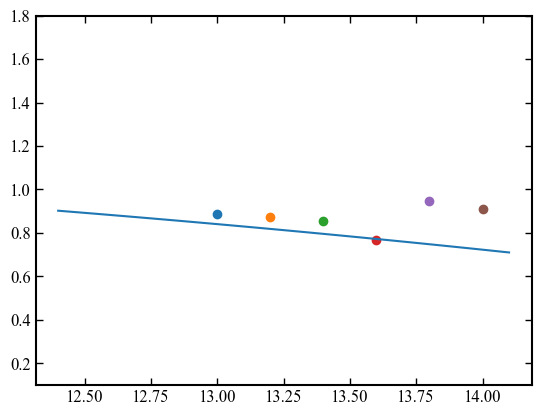

In [102]:
plt.plot(halo_smooth, np.log10(gh.c2_L16(10**halo_smooth, z=0)))

plt.scatter(np.log10(test130.mass[0,0]), np.log10(concentration_from_tree(test130.redshift, test130.mass[0])))
plt.scatter(np.log10(test132.mass[0,0]), np.log10(concentration_from_tree(test132.redshift, test132.mass[0])))
plt.scatter(np.log10(test134.mass[0,0]), np.log10(concentration_from_tree(test134.redshift, test134.mass[0])))
plt.scatter(np.log10(test136.mass[0,0]), np.log10(concentration_from_tree(test136.redshift, test136.mass[0])))
plt.scatter(np.log10(test138.mass[0,0]), np.log10(concentration_from_tree(test138.redshift, test138.mass[0])))
plt.scatter(np.log10(test140.mass[0,0]), np.log10(concentration_from_tree(test140.redshift, test140.mass[0])))

plt.ylim(0.1, 1.8)
